# **TEKNIK DETEKSI OUTLIER PADA DATASET HARGA RUMAH**

Dataset yang digunakan dalam tugas ini berasal dari platform Kaggle, yaitu House Prices Practice Dataset. Dataset ini memuat informasi mengenai karakteristik properti perumahan yang digunakan untuk analisis deteksi outlier.
Variabel yang digunakan meliputi:

*price* → harga properti

*area* → luas properti

*bedrooms* → jumlah kamar tidur

*bathrooms* → jumlah kamar mandi

Dataset ini dipilih karena memiliki variasi nilai yang memungkinkan identifikasi outlier, khususnya pada variabel harga dan luas, yang berpotensi mempengaruhi hasil analisis.

## **1. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Load Dataset**

In [2]:
df = pd.read_csv('house_prices_practice.csv')
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


## **3. Informasi Dataset**

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


## **4. Cek Nama Kolom**

In [4]:
df.columns

Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='str')

## **5. Visualisasi Boxplot**

### **Boxplot Harga Rumah**

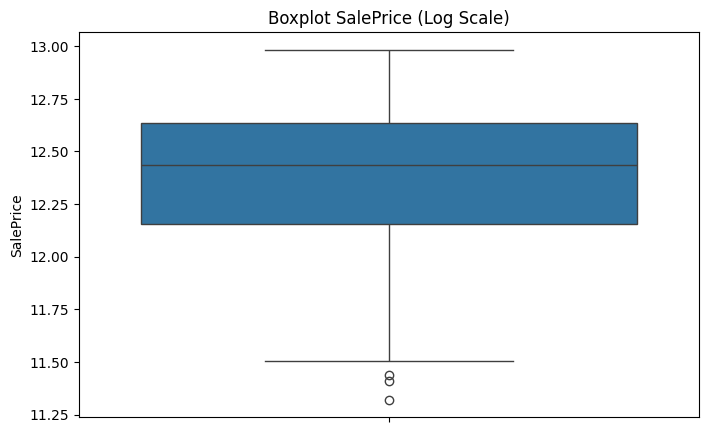

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(np.log(df['SalePrice']))
plt.title('Boxplot SalePrice (Log Scale)')
plt.show()

### **Boxplot Luas Rumah**

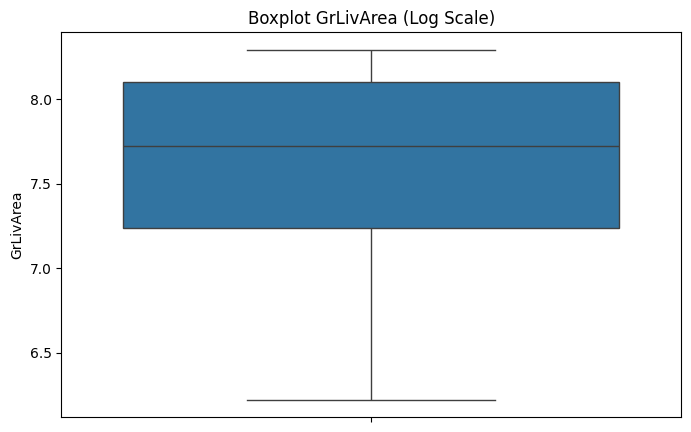

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(np.log(df['GrLivArea']))
plt.title('Boxplot GrLivArea (Log Scale)')
plt.show()

### **Penjelasan Boxplot**

Berdasarkan hasil boxplot, data luas rumah (*GrLivArea*) tidak menunjukkan adanya nilai yang menyimpang karena semua data masih berada dalam rentang yang wajar, sehingga ukuran rumah tergolong normal. Sementara itu, pada data harga rumah (*SalePrice*) terlihat beberapa titik yang berada di bawah batas utama, yang berarti terdapat beberapa rumah dengan harga jauh lebih murah dibandingkan mayoritas rumah lainnya. Hal ini menunjukkan adanya *outlier* pada variabel harga, sehingga dapat disimpulkan bahwa penyimpangan data lebih terjadi pada harga rumah dibandingkan luas rumah.


### **Penjelasan Outlier**

Berdasarkan hasil analisis, *outlier* pada variabel *SalePrice* merupakan data harga rumah yang berada jauh di bawah rentang harga mayoritas. Setelah menggunakan skala logaritmik, terlihat bahwa nilai outlier berada di sekitar **log(SalePrice) ≈ 11.3 – 11.5**, yang jika dikembalikan ke nilai asli setara dengan harga sekitar **Rp 80.000 – Rp 100.000 (dalam satuan dataset, misalnya USD ≈ 80.000–100.000)**. Nilai ini jauh lebih rendah dibandingkan sebagian besar rumah dalam dataset yang umumnya berada di kisaran harga lebih tinggi. Outlier ini kemungkinan merepresentasikan rumah dengan kondisi khusus, seperti lokasi kurang strategis, ukuran kecil, atau kondisi bangunan yang kurang layak. Sementara itu, pada variabel *GrLivArea* tidak ditemukan outlier yang signifikan, karena seluruh data masih berada dalam batas distribusi normal.
